<a href="https://colab.research.google.com/github/ChitiKatepa/FarmingDroneAI/blob/main/Flygawd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [140]:
import numpy as np
import pandas as pd

grid_size = 22

# Load severity map from sevmap.csv
severity_map_df = pd.read_csv('/content/sevmap2.csv', header=None)
severity_map = severity_map_df.values

In [141]:
import heapq

def astar(grid, start, goal):
    rows, cols = grid.shape

    def heuristic(a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            break

        neighbors = [
            (current[0]+1, current[1]),
            (current[0]-1, current[1]),
            (current[0], current[1]+1),
            (current[0], current[1]-1)
        ]

        for n in neighbors:
            if 0 <= n[0] < rows and 0 <= n[1] < cols:

                # Distance cost
                distance_cost = 1

                # Energy cost (same as distance for now)
                energy_cost = 1

                # Severity reward (encourage visiting high severity)
                severity_reward = grid[n]

                # Combined cost
                cost = distance_cost + energy_cost - severity_reward

                tentative_g = g_score[current] + cost

                if n not in g_score or tentative_g < g_score[n]:
                    g_score[n] = tentative_g
                    priority = tentative_g + heuristic(n, goal)
                    heapq.heappush(open_set, (priority, n))
                    came_from[n] = current

    # Reconstruct path
    path = []
    node = goal
    while node != start:
        path.append(node)
        node = came_from.get(node, start)
    path.append(start)

    return path[::-1]

In [142]:
start_pos = (14, 6)
energy = 0
coverage = 0

In [143]:
def simulate_path(path, severity_map):
    energy = 0
    coverage = 0
    sprayed = set()

    for i in range(len(path)-1):
        p1 = path[i]
        p2 = path[i+1]

        # Distance
        dist = abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])
        energy += dist

        # Spray logic
        if severity_map[p2] > 0.5:
            coverage += severity_map[p2]
            sprayed.add(p2)

    return energy, coverage, len(sprayed)


In [144]:
baseline_path = []

for i in range(grid_size):
    for j in range(grid_size):
        baseline_path.append((i, j))

In [145]:
#path = astar(severity_map, current_pos, (21, 21))
#path_back = astar(severity_map, (21, 21), end_pos)
#full_path = path + path_back[1:]

threshold = 0.4

targets = list(zip(*np.where(severity_map > threshold)))
targets = sorted(targets, key=lambda p: severity_map[p], reverse=True)

current = start_pos
full_path = []

for t in targets:
    segment = astar(severity_map, current, t)
    full_path += segment[:-1]
    current = t

# Return home
full_path += astar(severity_map, current, start_pos)

In [146]:
e1, c1, s1 = simulate_path(baseline_path, severity_map)
e2, c2, s2 = simulate_path(full_path, severity_map)

print("Baseline Energy:", e1)
print("A* Energy:", e2)

print("Baseline Coverage:", c1)
print("A* Coverage:", c2)

Baseline Energy: 924
A* Energy: 80
Baseline Coverage: 26.0
A* Coverage: 57.0


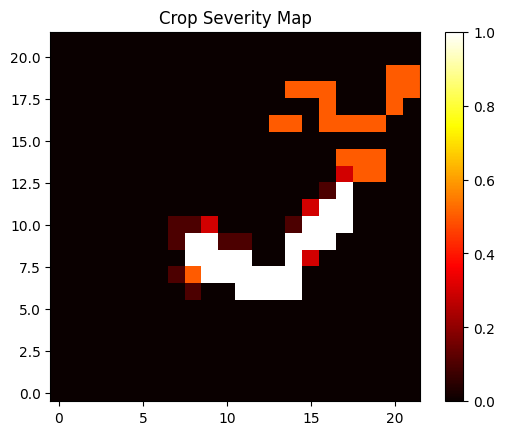

In [147]:
import matplotlib.pyplot as plt

plt.imshow(severity_map, cmap='hot')
plt.title("Crop Severity Map")
plt.colorbar()
plt.gca().invert_yaxis() # Invert the y-axis
plt.show()

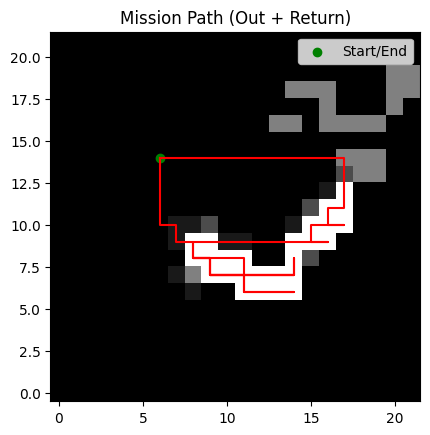

In [152]:
plt.imshow(severity_map, cmap='gray')

xs = [p[1] for p in full_path]
ys = [p[0] for p in full_path]

plt.plot(xs, ys, 'r-')
plt.scatter(start_pos[1], start_pos[0], c='green', label='Start/End')
plt.legend()
plt.title("Mission Path (Out + Return)")
plt.gca().invert_yaxis()
plt.show()

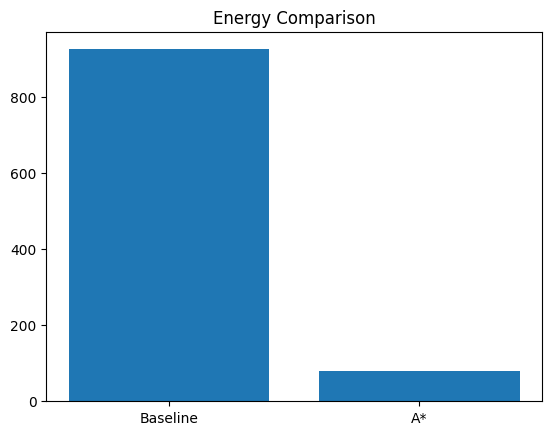

In [149]:
plt.bar(["Baseline", "A*"], [e1, e2])
plt.title("Energy Comparison")
plt.show()